# Module 05 — Cross-Dataset Integration

This notebook documents the cross-dataset integration produced by
`scripts/05_integration.py`. The 12 IVD scRNA-seq datasets (436,558 cells)
are integrated using a **tiered strategy** to avoid the "blob" problem where
standard batch correction erases biologically meaningful variation in IVD
resident cells:

- **Tier 1 — Non-resident cells** (immune, endothelial, pericyte): standard
  scVI integration with `batch_key='study'`. These populations have strong,
  discrete transcriptomic identities that survive standard batch correction.
  **Status: COMPLETE** (14,566 cells from 9 studies).

- **Tier 2 — Resident IVD cells**: NP and AF compartments to be integrated
  separately, benchmarked across four approaches (scVI, scANVI, Harmony, BBKNN).
  **Status: NOT YET RUN.** The code and approach stubs exist in
  `scripts/05_integration.py` but Tier 2 data files have not been generated.
  This module is at the **human checkpoint** for Tier 1 review before
  proceeding to Tier 2.

**Manuscript mapping:** Supplementary Figure S3 — integration benchmarking.
Methods section on integration strategy and rationale for chosen approach.

**Data sources:**
- `data/integrated/tier1_nonresident.h5ad` — Tier 1 integrated AnnData

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='scanpy')

from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})

# ── Paths ──────────────────────────────────────────────────────────────────
BASE = Path('..').resolve()
INT_DIR = BASE / 'data' / 'integrated'
RESULTS_DIR = BASE / 'results' / 'integration'
FIG_DIR = RESULTS_DIR
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Load metrics ──────────────────────────────────────────────────────────
metrics_path = RESULTS_DIR / 'integration_metrics.tsv'
if metrics_path.exists():
    metrics_df = pd.read_csv(metrics_path, sep='\t')
    print(f'Loaded metrics: {len(metrics_df)} rows')
    display(metrics_df)
else:
    metrics_df = pd.DataFrame()
    print('WARNING: integration_metrics.tsv not found — run the script first')

## Tier 1 — Non-Resident Cells

Non-resident cells (immune, endothelial, pericyte) were integrated with scVI
using `batch_key='study'`. After filtering to cells with a non-resident final
annotation from Module 04, this tier contains **14,566 cells from 9 studies**
(3 studies had no non-resident cells detected). These populations have strong,
discrete transcriptomic identities that survive standard batch correction.

The UMAPs below compare unintegrated vs scVI-corrected embeddings, colored by
study of origin, cell type, condition, and Leiden clusters.

Tier 1: 14,566 cells × 11,498 genes
Studies: 9
Cell types: 19

cell_type_final
Endothelial cells                6573
Macrophages                      1825
Tem/Trm cytotoxic T cells        1297
Tcm/Naive helper T cells          824
NK cells                          721
CD16+ NK cells                    594
Tem/Effector helper T cells       593
Plasma cells                      392
Naive B cells                     347
Tem/Temra cytotoxic T cells       284
Small pre-B cells                 246
DC                                202
Mast cells                        182
Memory B cells                    158
Pro-B cells                       129
Classical monocytes               106
B_cell                             90
Neutrophil-myeloid progenitor       2
Pericyte_SMC                        1
Name: count, dtype: int64

obsm keys: ['X_pca', 'X_pca_unintegrated', 'X_scvi', 'X_umap', 'X_umap_scvi', 'X_umap_unintegrated']


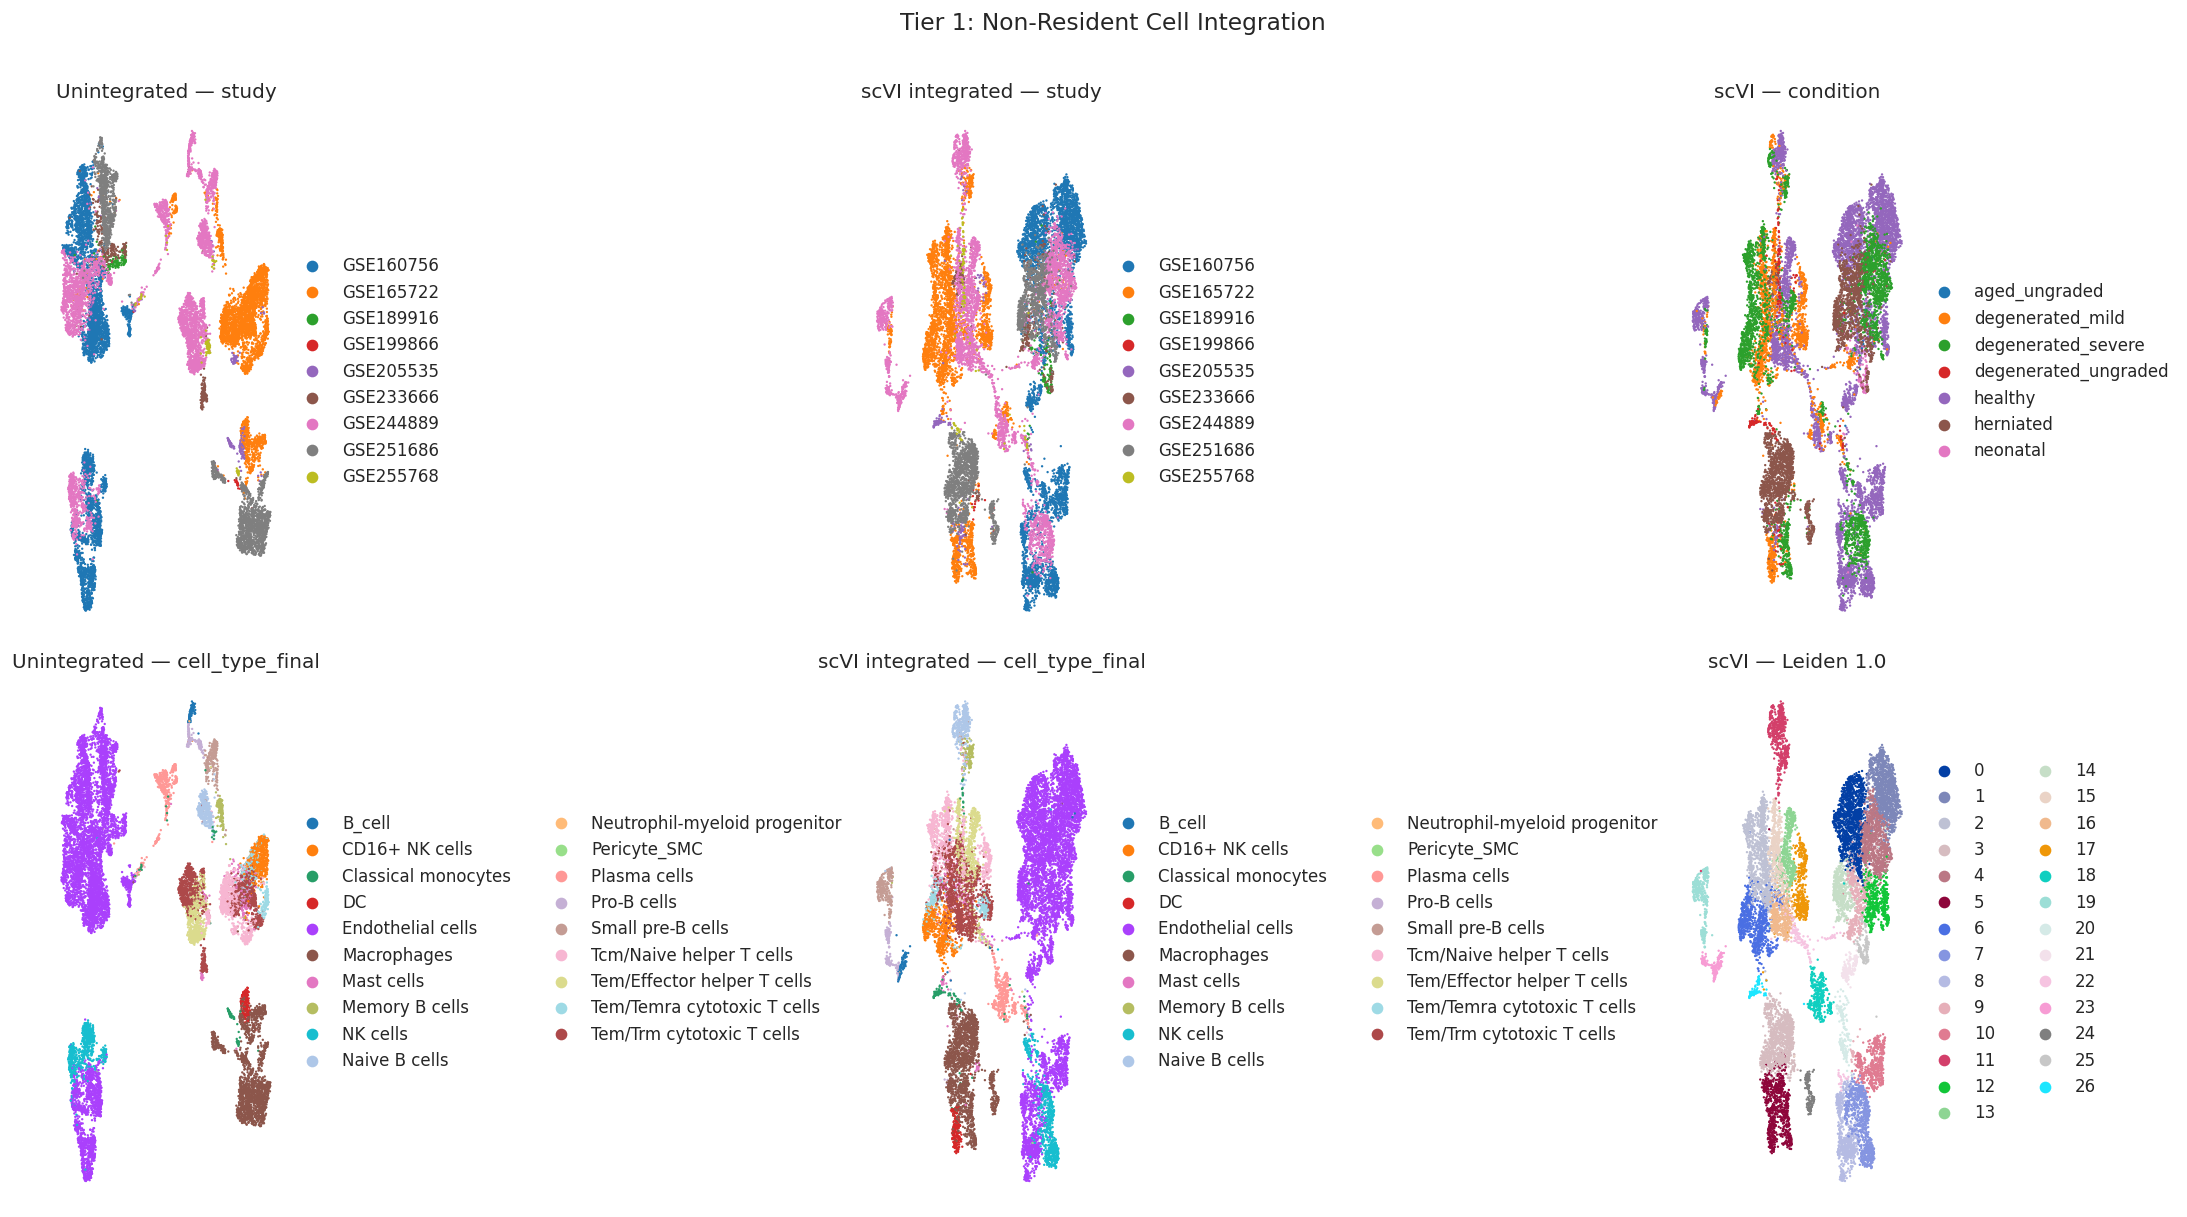

In [2]:
tier1_path = INT_DIR / 'tier1_nonresident.h5ad'

if tier1_path.exists():
    adata_t1 = sc.read_h5ad(tier1_path)
    print(f'Tier 1: {adata_t1.shape[0]:,} cells × {adata_t1.shape[1]:,} genes')
    print(f'Studies: {adata_t1.obs["study"].nunique()}')
    print(f'Cell types: {adata_t1.obs["cell_type_final"].nunique()}')
    print()
    print(adata_t1.obs['cell_type_final'].value_counts())
    print()
    print('obsm keys:', list(adata_t1.obsm.keys()))

    # UMAP — unintegrated vs scVI
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    for col_i, (umap_key, label) in enumerate([
        ('X_umap_unintegrated', 'Unintegrated'),
        ('X_umap_scvi', 'scVI integrated'),
    ]):
        if umap_key not in adata_t1.obsm:
            continue
        adata_t1.obsm['X_umap'] = adata_t1.obsm[umap_key]
        for row_i, color_key in enumerate(['study', 'cell_type_final']):
            ax = axes[row_i, col_i]
            sc.pl.umap(adata_t1, color=color_key, ax=ax, show=False,
                       frameon=False, s=8, title=f'{label} — {color_key}')

    # Third column: condition
    if 'X_umap_scvi' in adata_t1.obsm:
        adata_t1.obsm['X_umap'] = adata_t1.obsm['X_umap_scvi']
        if 'condition_harmonized' in adata_t1.obs.columns:
            sc.pl.umap(adata_t1, color='condition_harmonized', ax=axes[0, 2],
                       show=False, frameon=False, s=8, title='scVI — condition')
        if 'leiden_scvi_10' in adata_t1.obs.columns:
            sc.pl.umap(adata_t1, color='leiden_scvi_10', ax=axes[1, 2],
                       show=False, frameon=False, s=8, title='scVI — Leiden 1.0')

    fig.suptitle('Tier 1: Non-Resident Cell Integration', fontsize=14, y=1.01)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'notebook_05_tier1_umap.png', dpi=150, bbox_inches='tight')
    plt.show()
    del adata_t1
else:
    print('Tier 1 output not found')

## Tier 2 — Resident Cell Integration (Pending)

Tier 2 integration of resident IVD cells has not yet been executed.
The planned approach benchmarks four methods on NP and AF compartments
separately:
- **A** — scVI (conservative, n_latent=20, compartment covariate)
- **B** — scANVI (semi-supervised, high-confidence labels as seeds)
- **C** — Harmony (best theta from 0.5 / 1.0 / 2.0)
- **D** — BBKNN (graph-level batch correction)

The code below will display Tier 2 results when the data files are generated.
Until then, all resident cell analyses (Modules 06-09) use per-dataset
embeddings from Module 03/04.

In [3]:
def plot_approach_grid(adata, compartment, fig_dir):
    """Plot 5-column (unintegrated + 4 approaches) × 4-row (color keys) UMAP grid."""
    umap_keys = []
    umap_labels = []
    for key, label in [
        ('X_umap_unintegrated', 'Unintegrated'),
        ('X_umap_scvi', 'A: scVI'),
        ('X_umap_scanvi', 'B: scANVI'),
        ('X_umap_harmony', 'C: Harmony'),
        ('X_umap_bbknn', 'D: BBKNN'),
    ]:
        if key in adata.obsm:
            umap_keys.append(key)
            umap_labels.append(label)

    color_keys = ['study', 'cell_type_final', 'condition_harmonized', 'compartment']
    color_keys = [c for c in color_keys if c in adata.obs.columns]

    n_cols = len(umap_keys)
    n_rows = len(color_keys)
    if n_cols == 0:
        print(f'  No UMAP embeddings found for {compartment}')
        return

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]
    if n_cols == 1:
        axes = axes[:, np.newaxis]

    for col_i, (umap_key, umap_label) in enumerate(zip(umap_keys, umap_labels)):
        adata.obsm['X_umap'] = adata.obsm[umap_key]
        for row_i, color_key in enumerate(color_keys):
            ax = axes[row_i, col_i]
            sc.pl.umap(adata, color=color_key, ax=ax, show=False,
                       frameon=False, s=1, alpha=0.4)
            if row_i == 0:
                ax.set_title(umap_label, fontsize=11, fontweight='bold')
            if col_i == 0:
                ax.set_ylabel(color_key.replace('_', ' '), fontsize=10)

    fig.suptitle(f'Tier 2 {compartment}: Integration Approach Comparison',
                 fontsize=14, y=1.01)
    fig.tight_layout()
    fig.savefig(fig_dir / f'notebook_05_tier2_{compartment}_grid.png',
                dpi=150, bbox_inches='tight')
    plt.show()


np_path = INT_DIR / 'tier2_resident_NP.h5ad'
if np_path.exists():
    adata_np = sc.read_h5ad(np_path)
    print(f'NP: {adata_np.shape[0]:,} cells × {adata_np.shape[1]:,} genes')
    print(f'Studies: {adata_np.obs["study"].nunique()}')
    print(f'Cell types: {adata_np.obs["cell_type_final"].nunique()}')
    print(adata_np.obs['cell_type_final'].value_counts())
    print('obsm keys:', list(adata_np.obsm.keys()))
    print()
    plot_approach_grid(adata_np, 'NP', FIG_DIR)
else:
    adata_np = None
    print('Tier 2 NP output not found')

Tier 2 NP output not found


## Tier 2 AF — Approach Comparison (Pending)

AF resident cells (AF subtypes + fibroblasts) will be integrated separately
from NP cells. The same four approaches (A-D) will be compared. AF cells have
a clearer inner/outer distinction but the mechanical stress subtype may be
harder to preserve under aggressive batch correction.

The code below will populate when `tier2_resident_AF.h5ad` is generated.

In [4]:
af_path = INT_DIR / 'tier2_resident_AF.h5ad'
if af_path.exists():
    adata_af = sc.read_h5ad(af_path)
    print(f'AF: {adata_af.shape[0]:,} cells × {adata_af.shape[1]:,} genes')
    print(f'Studies: {adata_af.obs["study"].nunique()}')
    print(f'Cell types: {adata_af.obs["cell_type_final"].nunique()}')
    print(adata_af.obs['cell_type_final'].value_counts())
    print('obsm keys:', list(adata_af.obsm.keys()))
    print()
    plot_approach_grid(adata_af, 'AF', FIG_DIR)
else:
    adata_af = None
    print('Tier 2 AF output not found')

Tier 2 AF output not found


## Metrics Comparison (Pending Tier 2)

Once Tier 2 integration approaches are run, grouped bar charts will compare
batch mixing (iLISI, batch ASW) and biological conservation (cLISI, cell type
ASW, isolated label F1) across approaches. The overall scib score will weight
batch mixing at 40% and bio conservation at 60%, reflecting the priority of
preserving cell state information in this atlas.

No metrics are available yet because `integration_metrics.tsv` has not been
generated.

In [5]:
if len(metrics_df) > 0:
    # Separate Tier 2 metrics for NP and AF
    for compartment in ['NP', 'AF']:
        comp_df = metrics_df[metrics_df['compartment'] == compartment].copy()
        if len(comp_df) < 2:
            print(f'Skipping {compartment}: fewer than 2 approaches')
            continue

        metric_cols = ['iLISI', 'celltype_ASW', 'batch_ASW', 'isolated_label_F1', 'scib_overall']
        available = [c for c in metric_cols if c in comp_df.columns and comp_df[c].notna().any()]
        if not available:
            continue

        fig, ax = plt.subplots(figsize=(10, 5))
        x = np.arange(len(available))
        width = 0.8 / len(comp_df)

        for i, (_, row) in enumerate(comp_df.iterrows()):
            vals = [row.get(c, np.nan) for c in available]
            ax.bar(x + i * width, vals, width, label=row['approach'], alpha=0.8)

        ax.set_xticks(x + width * (len(comp_df) - 1) / 2)
        ax.set_xticklabels(available, rotation=30, ha='right')
        ax.set_ylabel('Score')
        ax.set_title(f'{compartment}: Integration Metrics Comparison')
        ax.legend()
        fig.tight_layout()
        fig.savefig(FIG_DIR / f'notebook_05_metrics_{compartment}.png',
                    dpi=150, bbox_inches='tight')
        plt.show()
else:
    print('No metrics available')

No metrics available


## Continuum Preservation — NP Score Distributions (Pending Tier 2)

The four NP signature scores (notochordal, mature chondrocyte, stressed/
degenerative, fibrocartilaginous) capture the cell state continuum. Once Tier 2
NP integration is complete, KDE plots of these scores — split by disease
condition — will reveal whether integration overcorrects and flattens the
condition-associated differences visible in per-dataset analysis (Module 04).

In [6]:
np_score_cols = ['score_NP_notochordal', 'score_NP_mature_chondrocyte',
                 'score_NP_stressed_degenerative', 'score_NP_fibrocartilaginous']

if adata_np is not None:
    available_scores = [c for c in np_score_cols if c in adata_np.obs.columns]
    if available_scores and 'condition_harmonized' in adata_np.obs.columns:
        conditions = sorted(adata_np.obs['condition_harmonized'].dropna().unique())

        fig, axes = plt.subplots(1, len(available_scores),
                                  figsize=(5 * len(available_scores), 5))
        if len(available_scores) == 1:
            axes = [axes]

        for ax, col in zip(axes, available_scores):
            for cond in conditions:
                data = adata_np.obs.loc[
                    adata_np.obs['condition_harmonized'] == cond, col
                ].dropna()
                if len(data) > 10:
                    data.plot.kde(ax=ax, label=cond, alpha=0.7)
            ax.set_title(col.replace('score_', '').replace('_', ' ').title(),
                         fontsize=10)
            ax.set_xlabel('Score')
            ax.legend(fontsize=7)

        fig.suptitle('NP Subtype Scores by Condition (Integrated Data)',
                     fontsize=12, y=1.02)
        fig.tight_layout()
        fig.savefig(FIG_DIR / 'notebook_05_np_continuum.png',
                    dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print('NP score columns or condition not available')
else:
    print('NP data not loaded')

NP data not loaded


## Cluster Count Comparison (Pending Tier 2)

A simple but informative check: how many Leiden clusters (at resolution 0.5)
does each approach produce? If an approach compresses everything into one or
two clusters, that is the "blob" problem. More clusters suggest better
preservation of biological heterogeneity — but too many may indicate failed
batch correction (batch-driven clusters).

In [7]:
if len(metrics_df) > 0 and 'n_clusters_05' in metrics_df.columns:
    tier2 = metrics_df[metrics_df['tier'] == 'tier2'].copy()
    if len(tier2) > 0 and tier2['n_clusters_05'].notna().any():
        fig, ax = plt.subplots(figsize=(10, 5))

        # Group by compartment
        compartments = tier2['compartment'].unique()
        x_positions = []
        x_labels = []
        colors = []
        palette = {'NP': '#3498db', 'AF': '#e74c3c'}

        pos = 0
        for comp in compartments:
            comp_data = tier2[tier2['compartment'] == comp]
            for _, row in comp_data.iterrows():
                ax.bar(pos, row['n_clusters_05'], color=palette.get(comp, '#95a5a6'),
                       alpha=0.8, edgecolor='white')
                x_positions.append(pos)
                x_labels.append(f"{row['approach']}\n({comp})")
                pos += 1
            pos += 0.5  # gap between compartments

        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels, fontsize=9)
        ax.set_ylabel('Number of clusters (resolution 0.5)')
        ax.set_title('Cluster Count by Integration Approach')
        ax.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Blob threshold')
        ax.legend()

        fig.tight_layout()
        fig.savefig(FIG_DIR / 'notebook_05_cluster_counts.png',
                    dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print('No cluster count data in Tier 2 metrics')
else:
    print('Cluster count data not available')

Cluster count data not available


## Condition Separability (Pending Tier 2)

A logistic regression classifier (5-fold CV) will be trained on each integrated
embedding to distinguish healthy from degenerated cells. Accuracy well above
chance (~50%) indicates that condition-associated transcriptomic variation
survived integration.

In [8]:
if len(metrics_df) > 0 and 'condition_accuracy' in metrics_df.columns:
    tier2 = metrics_df[metrics_df['tier'] == 'tier2'].copy()
    if len(tier2) > 0 and tier2['condition_accuracy'].notna().any():
        fig, ax = plt.subplots(figsize=(10, 5))

        compartments = tier2['compartment'].unique()
        palette = {'NP': '#3498db', 'AF': '#e74c3c'}
        pos = 0
        x_positions = []
        x_labels = []

        for comp in compartments:
            comp_data = tier2[tier2['compartment'] == comp]
            for _, row in comp_data.iterrows():
                ax.bar(pos, row['condition_accuracy'],
                       color=palette.get(comp, '#95a5a6'),
                       alpha=0.8, edgecolor='white')
                x_positions.append(pos)
                x_labels.append(f"{row['approach']}\n({comp})")
                pos += 1
            pos += 0.5

        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels, fontsize=9)
        ax.set_ylabel('Accuracy')
        ax.set_title('Condition Separability (5-Fold CV Logistic Regression)')
        ax.axhline(y=0.5, color='grey', linestyle='--', alpha=0.5, label='Chance')
        ax.axhline(y=0.6, color='green', linestyle='--', alpha=0.5, label='60% threshold')
        ax.set_ylim(0, 1)
        ax.legend()

        fig.tight_layout()
        fig.savefig(FIG_DIR / 'notebook_05_condition_accuracy.png',
                    dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print('No condition accuracy data in Tier 2 metrics')
else:
    print('Condition accuracy not available')

Condition accuracy not available


## Full Metrics Table (Pending Tier 2)

Once generated, the complete metrics table will cover all tiers, compartments,
and approaches. The "best" approach per compartment will be highlighted by the
highest `scib_overall` score (40% batch mixing + 60% biological conservation).

In [9]:
if len(metrics_df) > 0:
    # Highlight best per compartment
    display_cols = ['tier', 'compartment', 'approach', 'iLISI', 'cLISI',
                    'batch_ASW', 'celltype_ASW', 'isolated_label_F1',
                    'scib_overall', 'n_clusters_05', 'condition_accuracy']
    available_cols = [c for c in display_cols if c in metrics_df.columns]
    display_df = metrics_df[available_cols].copy()

    # Round numeric columns
    for col in display_df.select_dtypes(include='number').columns:
        display_df[col] = display_df[col].round(3)

    def highlight_best(s):
        if s.name != 'scib_overall' or s.isna().all():
            return ['' for _ in s]
        is_max = s == s.max()
        return ['background-color: #d5f5e3' if v else '' for v in is_max]

    display(
        display_df.style
        .apply(highlight_best, axis=0)
        .set_caption('Integration Metrics Summary')
    )
else:
    print('No metrics to display')

No metrics to display


## Current Status and Human Checkpoint

### What is complete
- **Tier 1** (non-resident cells): scVI integration of 14,566 immune, endothelial,
  and pericyte cells from 9 studies. UMAPs and Leiden clustering generated.
  The scVI model is saved in `data/integrated/models/`.

### What is pending
- **Tier 2** (resident cells): NP and AF integration across 4 approaches (A-D)
  has not been run. The script exists but the data files
  (`tier2_resident_NP.h5ad`, `tier2_resident_AF.h5ad`) and metrics
  (`integration_metrics.tsv`) have not been generated.
- **Approaches E and F** (metacell aggregation, label transfer without
  integration): documented as fallbacks in the spec if approaches A-D
  overcorrect. Not yet implemented.

### Questions for review
1. Does the Tier 1 integration look reasonable? Are immune subtypes well-separated
   while batch effects are reduced?
2. Should Tier 2 be run as planned, or should the approach be modified based on
   what we see in per-dataset analyses (Modules 03-04)?
3. Which Tier 2 approaches are highest priority to run first?
4. Should the analysis proceed with integrated data, per-dataset data, or both
   in parallel for downstream modules?

In [10]:
# Clean up large objects
for var in ['adata_np', 'adata_af']:
    if var in dir():
        exec(f'del {var}')

saved_figures = sorted(FIG_DIR.glob('notebook_05_*.png'))
print('Saved figures:')
for f in saved_figures:
    print(f'  {f.relative_to(BASE)}')

Saved figures:
  results/integration/notebook_05_tier1_umap.png
